In [ ]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.metrics import (
        ConfusionMatrixDisplay,
        accuracy_score,
        classification_report,
        confusion_matrix,
        f1_score
    )
from torch.utils.data import DataLoader
from torchvision import datasets, models, transforms

In [ ]:
BATCH_SIZE = 32
NUM_EPOCHS = 10
LR = 3e-4
NUM_CLASSES = 5
NUM_WORKERS = 4
SEED = 42

if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

torch.manual_seed(SEED)

In [ ]:
# resize -> center crop -> ImageNet normalization (matched to the pretrained weights)
weights = models.ConvNeXt_Tiny_Weights.IMAGENET1K_V1
preprocess = weights.transforms()

train_ds = datasets.ImageFolder("flower-splits/train", transform=preprocess)
val_ds   = datasets.ImageFolder("flower-splits/val",   transform=preprocess)
test_ds  = datasets.ImageFolder("flower-splits/test",  transform=preprocess)

labels = train_ds.classes

train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                      num_workers=NUM_WORKERS, pin_memory=False,
                      persistent_workers=NUM_WORKERS > 0)
val_dl   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                      num_workers=NUM_WORKERS, pin_memory=False,
                      persistent_workers=NUM_WORKERS > 0)
test_dl  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                      num_workers=NUM_WORKERS, pin_memory=False,
                      persistent_workers=NUM_WORKERS > 0)

In [ ]:
# ConvNeXt-Tiny: modern CNN (2022), ~28M params, ~82.5% ImageNet top-1.
# Its classifier head is Sequential(LayerNorm2d, Flatten, Linear) -> replace the Linear.
class FlowerNet(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES):
        super().__init__()
        self.backbone = models.convnext_tiny(
            weights=models.ConvNeXt_Tiny_Weights.IMAGENET1K_V1
        )
        in_features = self.backbone.classifier[2].in_features
        self.backbone.classifier[2] = nn.Linear(in_features, num_classes)

    def forward(self, x):
        return self.backbone(x)

In [ ]:
# Run inference on a single batch and return predicted class indices.
def predict_classes(model, x):
    model.eval()
    with torch.no_grad():
        logits = model(x.to(device))
        return logits.argmax(dim=1)

In [ ]:
def evaluate(model, dl, labels):
    model.eval()
    criterion = nn.CrossEntropyLoss(reduction="sum")

    all_preds, all_targets = [], []
    total_loss, total_count = 0.0, 0

    with torch.no_grad():
        for x, y in dl:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            total_loss += criterion(logits, y).item()
            total_count += y.size(0)
            all_preds.append(logits.argmax(dim=1).cpu())
            all_targets.append(y.cpu())

    y_pred = torch.cat(all_preds).numpy()
    y_true = torch.cat(all_targets).numpy()

    return {
        "loss":     total_loss / total_count,
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro"),
        "cm":       confusion_matrix(y_true, y_pred),
        "report":   classification_report(y_true, y_pred,
                                          target_names=labels,
                                          digits=4, zero_division=0),
    }


# Sanity check: evaluate runs end-to-end on a freshly-instantiated model.
# Pretrained backbone + random head -> predictions should be ~chance (~20%).
# Guarded so DataLoader workers don't re-run training when they re-import this file.
if __name__ == "__main__":
    _sanity = FlowerNet().to(device)
    _metrics = evaluate(_sanity, val_dl, labels)
    print(f"[sanity] untrained val: acc={_metrics['accuracy']:.4f} "
          f"macro_f1={_metrics['macro_f1']:.4f} loss={_metrics['loss']:.4f}")
    del _sanity

Downloading: "https://download.pytorch.org/models/convnext_tiny-983f1562.pth" to /Users/axellangenskiold/.cache/torch/hub/checkpoints/convnext_tiny-983f1562.pth


100%|██████████| 109M/109M [00:03<00:00, 37.7MB/s] 


[sanity] untrained val: acc=0.1505 macro_f1=0.1358 loss=1.6809


In [ ]:
def train(model, optimizer, train_dl, val_dl, num_epochs, name, scheduler=None):
    criterion = nn.CrossEntropyLoss()
    out_dir = Path("runs") / name
    out_dir.mkdir(parents=True, exist_ok=True)

    history = {"train_loss": [], "train_acc": [],
               "val_loss":   [], "val_acc":   [], "val_macro_f1": []}
    best_val_f1 = -1.0

    for epoch in range(1, num_epochs + 1):
        model.train()
        running_loss, running_correct, running_total = 0.0, 0, 0

        for x, y in train_dl:
            x, y = x.to(device), y.to(device)

            optimizer.zero_grad()
            logits = model(x)
            loss = criterion(logits, y)
            loss.backward()
            optimizer.step()

            running_loss    += loss.item() * y.size(0)
            running_correct += (logits.argmax(dim=1) == y).sum().item()
            running_total   += y.size(0)

        if scheduler is not None:
            scheduler.step()

        train_loss = running_loss    / running_total
        train_acc  = running_correct / running_total
        val = evaluate(model, val_dl, labels)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val["loss"])
        history["val_acc"].append(val["accuracy"])
        history["val_macro_f1"].append(val["macro_f1"])

        print(f"[{name}] epoch {epoch}/{num_epochs}  "
              f"train: loss={train_loss:.4f} acc={train_acc:.4f}  |  "
              f"val: loss={val['loss']:.4f} acc={val['accuracy']:.4f} "
              f"f1={val['macro_f1']:.4f}")

        if val["macro_f1"] > best_val_f1:
            best_val_f1 = val["macro_f1"]
            torch.save(model.state_dict(), out_dir / "best.pt")

    torch.save(model.state_dict(), out_dir / "last.pt")
    with open(out_dir / "history.json", "w") as f:
        json.dump(history, f, indent=2)

    return history

In [ ]:
if __name__ == "__main__":
    model = FlowerNet().to(device)

    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
    # Cosine schedule: smoothly decays LR from initial value to ~0 over the run.
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)
    baseline_history = train(model, optimizer, train_dl, val_dl,
                             num_epochs=NUM_EPOCHS, name="baseline",
                             scheduler=scheduler)

[baseline] epoch 1/10  train: loss=0.3852 acc=0.8571  |  val: loss=0.2236 acc=0.9259 f1=0.9244
[baseline] epoch 2/10  train: loss=0.0788 acc=0.9764  |  val: loss=0.1647 acc=0.9421 f1=0.9418
[baseline] epoch 3/10  train: loss=0.0365 acc=0.9888  |  val: loss=0.2223 acc=0.9340 f1=0.9317
[baseline] epoch 4/10  train: loss=0.0242 acc=0.9930  |  val: loss=0.1750 acc=0.9549 f1=0.9537
[baseline] epoch 5/10  train: loss=0.0113 acc=0.9961  |  val: loss=0.1512 acc=0.9572 f1=0.9557
[baseline] epoch 6/10  train: loss=0.0023 acc=0.9996  |  val: loss=0.1418 acc=0.9630 f1=0.9620
[baseline] epoch 7/10  train: loss=0.0023 acc=0.9992  |  val: loss=0.1421 acc=0.9595 f1=0.9584
[baseline] epoch 8/10  train: loss=0.0017 acc=0.9996  |  val: loss=0.1382 acc=0.9653 f1=0.9646
[baseline] epoch 9/10  train: loss=0.0012 acc=0.9996  |  val: loss=0.1378 acc=0.9653 f1=0.9646
[baseline] epoch 10/10  train: loss=0.0014 acc=0.9996  |  val: loss=0.1378 acc=0.9664 f1=0.9659


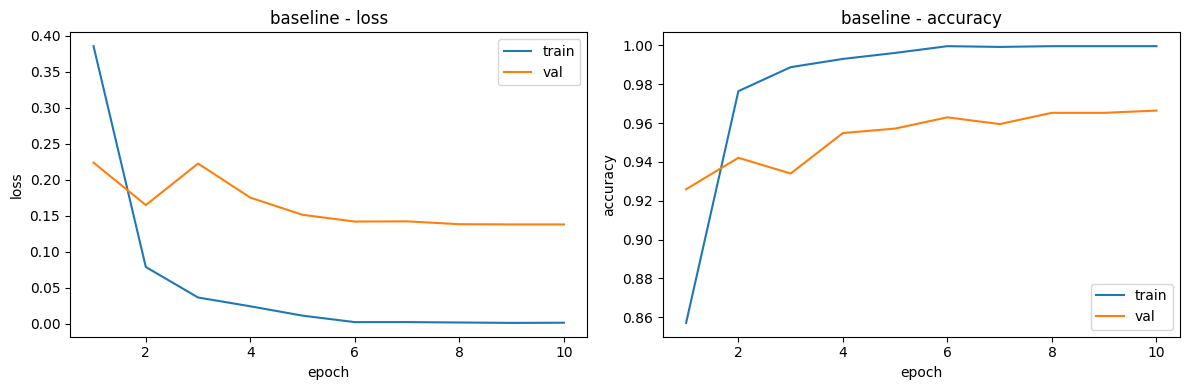


=== baseline / train ===
loss=0.0008  acc=0.9996  macro_f1=0.9996
              precision    recall  f1-score   support

       daisy     1.0000    1.0000    1.0000       458
   dandelion     1.0000    1.0000    1.0000       631
        rose     1.0000    0.9979    0.9989       470
   sunflower     1.0000    1.0000    1.0000       440
       tulip     0.9983    1.0000    0.9992       590

    accuracy                         0.9996      2589
   macro avg     0.9997    0.9996    0.9996      2589
weighted avg     0.9996    0.9996    0.9996      2589



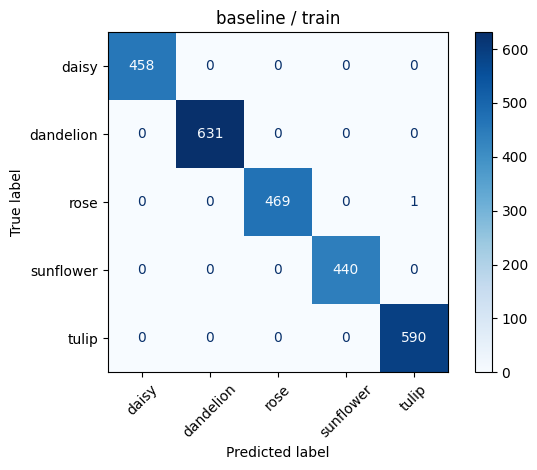


=== baseline / val ===
loss=0.1378  acc=0.9664  macro_f1=0.9659
              precision    recall  f1-score   support

       daisy     0.9735    0.9608    0.9671       153
   dandelion     0.9587    0.9952    0.9766       210
        rose     0.9675    0.9490    0.9582       157
   sunflower     0.9724    0.9592    0.9658       147
       tulip     0.9643    0.9594    0.9618       197

    accuracy                         0.9664       864
   macro avg     0.9673    0.9647    0.9659       864
weighted avg     0.9665    0.9664    0.9664       864



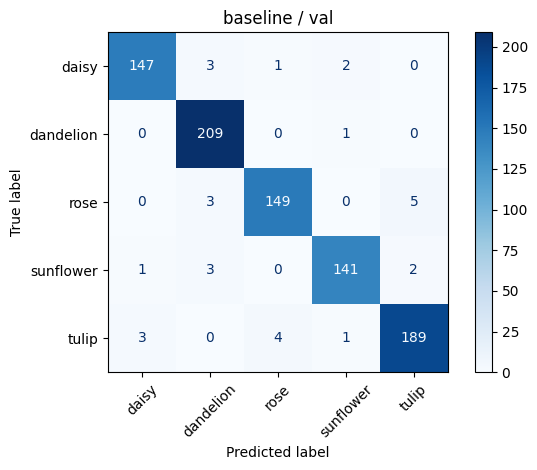


=== baseline / test ===
loss=0.1699  acc=0.9583  macro_f1=0.9586
              precision    recall  f1-score   support

       daisy     0.9600    0.9412    0.9505       153
   dandelion     0.9577    0.9668    0.9623       211
        rose     0.9268    0.9682    0.9470       157
   sunflower     0.9730    0.9863    0.9796       146
       tulip     0.9735    0.9340    0.9534       197

    accuracy                         0.9583       864
   macro avg     0.9582    0.9593    0.9586       864
weighted avg     0.9587    0.9583    0.9583       864



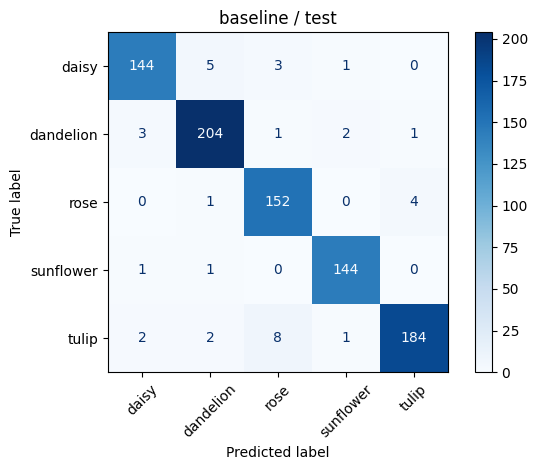

In [ ]:
def plot_history(history, name):
    """Save train/val loss + accuracy curves to runs/<name>/curves.png."""
    epochs = range(1, len(history["train_loss"]) + 1)
    fig, (ax_loss, ax_acc) = plt.subplots(1, 2, figsize=(12, 4))

    ax_loss.plot(epochs, history["train_loss"], label="train")
    ax_loss.plot(epochs, history["val_loss"],   label="val")
    ax_loss.set(xlabel="epoch", ylabel="loss", title=f"{name} - loss")
    ax_loss.legend()

    ax_acc.plot(epochs, history["train_acc"], label="train")
    ax_acc.plot(epochs, history["val_acc"],   label="val")
    ax_acc.set(xlabel="epoch", ylabel="accuracy", title=f"{name} - accuracy")
    ax_acc.legend()

    fig.tight_layout()
    fig.savefig(Path("runs") / name / "curves.png", dpi=120, bbox_inches="tight")
    plt.show()

def full_eval(model, name, dls=None):
    """Report loss/accuracy/macro-F1 + classification report on all splits."""
    if dls is None:
        dls = [("train", train_dl), ("val", val_dl), ("test", test_dl)]
    for split_name, dl in dls:
        m = evaluate(model, dl, labels)
        print(f"\n=== {name} / {split_name} ===")
        print(f"loss={m['loss']:.4f}  acc={m['accuracy']:.4f}  "
              f"macro_f1={m['macro_f1']:.4f}")
        print(m["report"])
        disp = ConfusionMatrixDisplay(confusion_matrix=m["cm"],
                                      display_labels=labels)
        disp.plot(cmap="Blues", values_format="d", xticks_rotation=45)
        plt.title(f"{name} / {split_name}")
        plt.tight_layout()
        plt.show()

# Reload the best checkpoint (highest val macro-F1) for reporting.
if __name__ == "__main__":
    model.load_state_dict(torch.load("runs/baseline/best.pt", map_location=device))
    plot_history(baseline_history, "baseline")
    full_eval(model, "baseline")

In [ ]:
# Reuse the matched preprocessing's crop size + normalization so the augmented
# pipeline ends in the exact same value range the pretrained backbone expects.
train_aug_transform = transforms.Compose([
    transforms.RandomResizedCrop(preprocess.crop_size[0], scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(mean=preprocess.mean, std=preprocess.std),
])

train_aug_ds = datasets.ImageFolder("flower-splits/train",
                                    transform=train_aug_transform)
train_aug_dl = DataLoader(train_aug_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=False,
                          persistent_workers=NUM_WORKERS > 0)

if __name__ == "__main__":
    model_aug = FlowerNet().to(device)
    optimizer_aug = torch.optim.AdamW(model_aug.parameters(), lr=LR, weight_decay=1e-4)
    scheduler_aug = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer_aug, T_max=NUM_EPOCHS * 2)
    aug_history = train(model_aug, optimizer_aug, train_aug_dl, val_dl,
                        num_epochs=NUM_EPOCHS * 2, name="aug",
                        scheduler=scheduler_aug)

[aug] epoch 1/20  train: loss=0.3978 acc=0.8575  |  val: loss=0.2657 acc=0.9051 f1=0.9018
[aug] epoch 2/20  train: loss=0.1442 acc=0.9498  |  val: loss=0.1922 acc=0.9433 f1=0.9429
[aug] epoch 3/20  train: loss=0.0997 acc=0.9668  |  val: loss=0.1422 acc=0.9572 f1=0.9572
[aug] epoch 4/20  train: loss=0.0705 acc=0.9757  |  val: loss=0.1976 acc=0.9329 f1=0.9309
[aug] epoch 5/20  train: loss=0.0936 acc=0.9706  |  val: loss=0.1536 acc=0.9433 f1=0.9438
[aug] epoch 6/20  train: loss=0.0608 acc=0.9795  |  val: loss=0.3131 acc=0.9005 f1=0.9012
[aug] epoch 7/20  train: loss=0.0408 acc=0.9873  |  val: loss=0.1493 acc=0.9525 f1=0.9522
[aug] epoch 8/20  train: loss=0.0280 acc=0.9892  |  val: loss=0.1676 acc=0.9537 f1=0.9530
[aug] epoch 9/20  train: loss=0.0174 acc=0.9934  |  val: loss=0.1417 acc=0.9560 f1=0.9559
[aug] epoch 10/20  train: loss=0.0064 acc=0.9981  |  val: loss=0.1380 acc=0.9606 f1=0.9597
[aug] epoch 11/20  train: loss=0.0030 acc=0.9996  |  val: loss=0.1337 acc=0.9630 f1=0.9625
[aug] ep

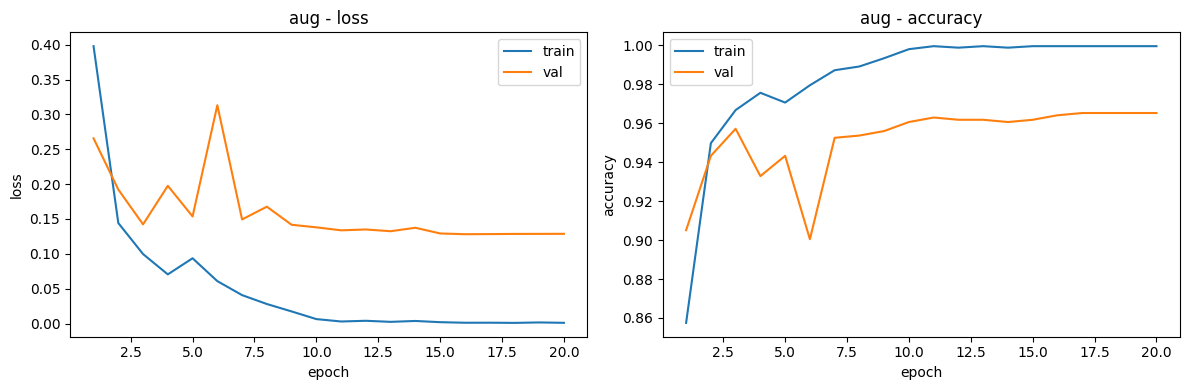


=== aug / train ===
loss=0.0021  acc=0.9992  macro_f1=0.9992
              precision    recall  f1-score   support

       daisy     1.0000    1.0000    1.0000       458
   dandelion     1.0000    1.0000    1.0000       631
        rose     1.0000    0.9957    0.9979       470
   sunflower     0.9977    1.0000    0.9989       440
       tulip     0.9983    1.0000    0.9992       590

    accuracy                         0.9992      2589
   macro avg     0.9992    0.9991    0.9992      2589
weighted avg     0.9992    0.9992    0.9992      2589



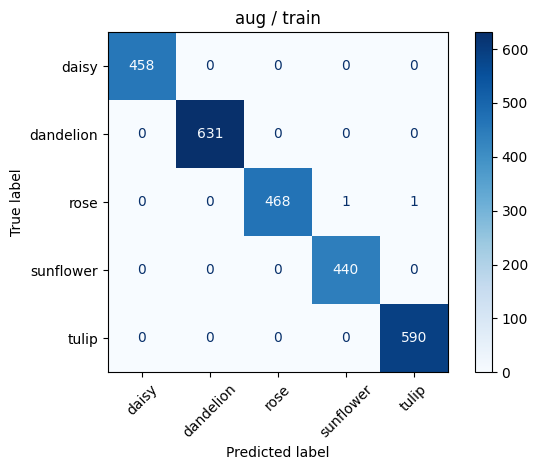


=== aug / val ===
loss=0.1283  acc=0.9653  macro_f1=0.9648
              precision    recall  f1-score   support

       daisy     0.9739    0.9739    0.9739       153
   dandelion     0.9811    0.9905    0.9858       210
        rose     0.9481    0.9299    0.9389       157
   sunflower     0.9861    0.9660    0.9759       147
       tulip     0.9403    0.9594    0.9497       197

    accuracy                         0.9653       864
   macro avg     0.9659    0.9639    0.9648       864
weighted avg     0.9654    0.9653    0.9653       864



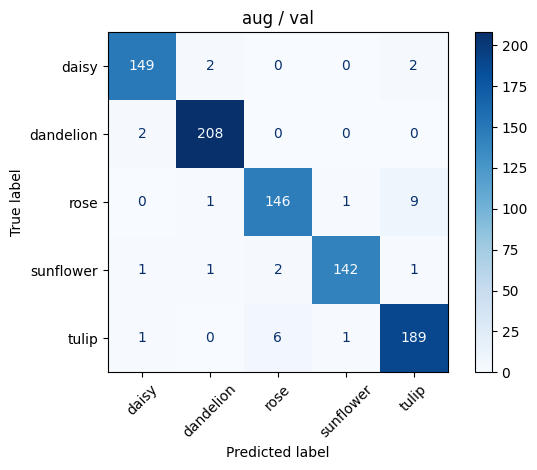


=== aug / test ===
loss=0.1790  acc=0.9583  macro_f1=0.9588
              precision    recall  f1-score   support

       daisy     0.9796    0.9412    0.9600       153
   dandelion     0.9624    0.9716    0.9670       211
        rose     0.9545    0.9363    0.9453       157
   sunflower     0.9667    0.9932    0.9797       146
       tulip     0.9350    0.9492    0.9421       197

    accuracy                         0.9583       864
   macro avg     0.9596    0.9583    0.9588       864
weighted avg     0.9585    0.9583    0.9583       864



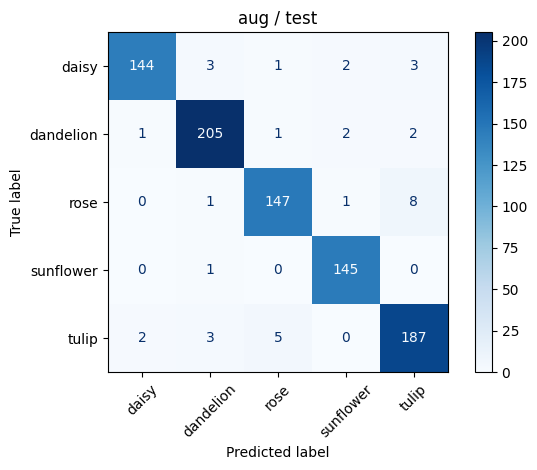

In [ ]:
if __name__ == "__main__":
    model_aug.load_state_dict(torch.load("runs/aug/best.pt", map_location=device))
    plot_history(aug_history, "aug")
    full_eval(model_aug, "aug")

In [ ]:
# Swap the backbone family entirely: EfficientNet-B0 (~5M params, mobile-inverted
# bottlenecks) vs ResNet50 (~25M params, residual conv blocks). Same ImageNet
# pretraining, but its weights ship with their own resize/crop and normalization
# stats, so we build matched train/eval transforms for it.
class FlowerNetEffNet(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES):
        super().__init__()
        self.backbone = models.efficientnet_b0(
            weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1
        )
        in_features = self.backbone.classifier[1].in_features
        self.backbone.classifier[1] = nn.Linear(in_features, num_classes)

    def forward(self, x):
        return self.backbone(x)

effnet_weights    = models.EfficientNet_B0_Weights.IMAGENET1K_V1
effnet_preprocess = effnet_weights.transforms()

train_effnet_transform = transforms.Compose([
    transforms.RandomResizedCrop(effnet_preprocess.crop_size[0], scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(mean=effnet_preprocess.mean, std=effnet_preprocess.std),
])

train_effnet_ds = datasets.ImageFolder("flower-splits/train",
                                       transform=train_effnet_transform)
val_effnet_ds   = datasets.ImageFolder("flower-splits/val",
                                       transform=effnet_preprocess)
test_effnet_ds  = datasets.ImageFolder("flower-splits/test",
                                       transform=effnet_preprocess)

train_effnet_dl = DataLoader(train_effnet_ds, batch_size=BATCH_SIZE, shuffle=True,
                             num_workers=NUM_WORKERS, pin_memory=False,
                             persistent_workers=NUM_WORKERS > 0)
val_effnet_dl   = DataLoader(val_effnet_ds,   batch_size=BATCH_SIZE, shuffle=False,
                             num_workers=NUM_WORKERS, pin_memory=False,
                             persistent_workers=NUM_WORKERS > 0)
test_effnet_dl  = DataLoader(test_effnet_ds,  batch_size=BATCH_SIZE, shuffle=False,
                             num_workers=NUM_WORKERS, pin_memory=False,
                             persistent_workers=NUM_WORKERS > 0)

In [ ]:
if __name__ == "__main__":
    model_effnet     = FlowerNetEffNet().to(device)
    optimizer_effnet = torch.optim.AdamW(model_effnet.parameters(),
                                         lr=LR, weight_decay=1e-4)
    scheduler_effnet = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer_effnet, T_max=NUM_EPOCHS * 2)
    effnet_history   = train(model_effnet, optimizer_effnet,
                             train_effnet_dl, val_effnet_dl,
                             num_epochs=NUM_EPOCHS * 2, name="effnet",
                             scheduler=scheduler_effnet)

[effnet] epoch 1/20  train: loss=0.5741 acc=0.8100  |  val: loss=0.2006 acc=0.9433 f1=0.9431
[effnet] epoch 2/20  train: loss=0.2249 acc=0.9274  |  val: loss=0.2051 acc=0.9387 f1=0.9383
[effnet] epoch 3/20  train: loss=0.1379 acc=0.9552  |  val: loss=0.1739 acc=0.9433 f1=0.9425
[effnet] epoch 4/20  train: loss=0.0919 acc=0.9695  |  val: loss=0.1933 acc=0.9410 f1=0.9398
[effnet] epoch 5/20  train: loss=0.0881 acc=0.9710  |  val: loss=0.1698 acc=0.9456 f1=0.9458
[effnet] epoch 6/20  train: loss=0.0675 acc=0.9799  |  val: loss=0.1584 acc=0.9525 f1=0.9524
[effnet] epoch 7/20  train: loss=0.0599 acc=0.9795  |  val: loss=0.1574 acc=0.9433 f1=0.9424
[effnet] epoch 8/20  train: loss=0.0505 acc=0.9838  |  val: loss=0.1356 acc=0.9525 f1=0.9525
[effnet] epoch 9/20  train: loss=0.0298 acc=0.9919  |  val: loss=0.1352 acc=0.9549 f1=0.9538
[effnet] epoch 10/20  train: loss=0.0217 acc=0.9934  |  val: loss=0.1306 acc=0.9618 f1=0.9613
[effnet] epoch 11/20  train: loss=0.0183 acc=0.9946  |  val: loss=0.1

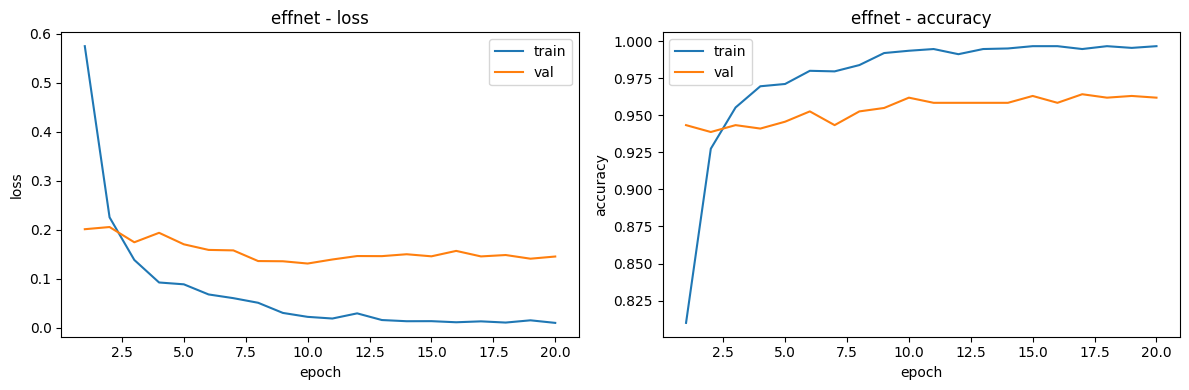


=== effnet / train ===
loss=0.0013  acc=0.9992  macro_f1=0.9992
              precision    recall  f1-score   support

       daisy     1.0000    1.0000    1.0000       458
   dandelion     1.0000    1.0000    1.0000       631
        rose     0.9979    0.9979    0.9979       470
   sunflower     1.0000    1.0000    1.0000       440
       tulip     0.9983    0.9983    0.9983       590

    accuracy                         0.9992      2589
   macro avg     0.9992    0.9992    0.9992      2589
weighted avg     0.9992    0.9992    0.9992      2589



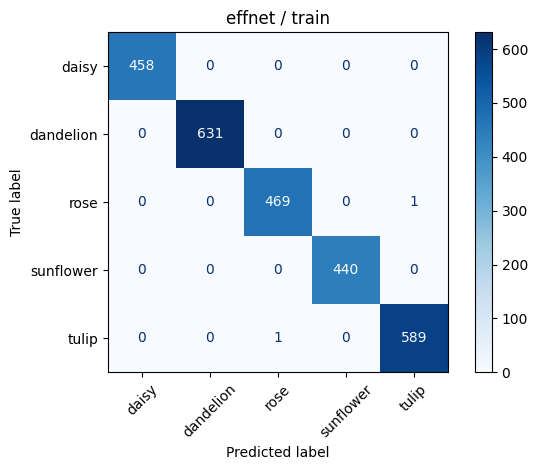


=== effnet / val ===
loss=0.1451  acc=0.9641  macro_f1=0.9636
              precision    recall  f1-score   support

       daisy     0.9799    0.9542    0.9669       153
   dandelion     0.9764    0.9857    0.9810       210
        rose     0.9608    0.9363    0.9484       157
   sunflower     0.9726    0.9660    0.9693       147
       tulip     0.9363    0.9695    0.9526       197

    accuracy                         0.9641       864
   macro avg     0.9652    0.9624    0.9636       864
weighted avg     0.9644    0.9641    0.9641       864



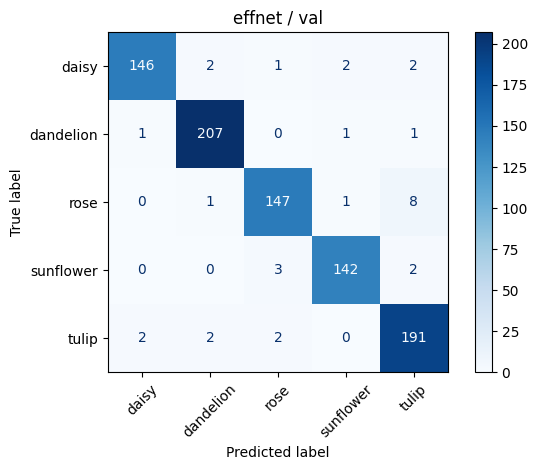


=== effnet / test ===
loss=0.1876  acc=0.9514  macro_f1=0.9506
              precision    recall  f1-score   support

       daisy     0.9467    0.9281    0.9373       153
   dandelion     0.9804    0.9479    0.9639       211
        rose     0.9207    0.9618    0.9408       157
   sunflower     0.9467    0.9726    0.9595       146
       tulip     0.9541    0.9492    0.9517       197

    accuracy                         0.9514       864
   macro avg     0.9497    0.9519    0.9506       864
weighted avg     0.9519    0.9514    0.9514       864



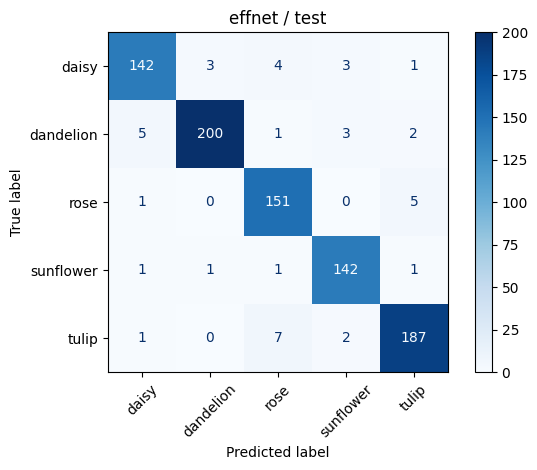

In [ ]:
if __name__ == "__main__":
    model_effnet.load_state_dict(torch.load("runs/effnet/best.pt",
                                            map_location=device))
    plot_history(effnet_history, "effnet")
    full_eval(model_effnet, "effnet",
              dls=[("train", train_effnet_dl),
                   ("val",   val_effnet_dl),
                   ("test",  test_effnet_dl)])